In [ ]:
#import all required libraries
import os
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
from transformers import AutoTokenizer, AutoModelForCausalLM # for conversational chatbot

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report

#Part 1: Convolutional Neural Network
### Crack Detection on Concrete Surfaces

In [ ]:
# load in dataset
import kagglehub

# Download latest version
path = kagglehub.dataset_download("arunrk7/surface-crack-detection")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'surface-crack-detection' dataset.
Path to dataset files: /kaggle/input/surface-crack-detection


#### Preprocessing images
We resize each image, convert it to tensors, and normalize pixel values so the CNN receives data in a consistent format.

In [ ]:
# Define image preprocessing: resize to 64x64, convert to tensor, normalize pixel values
# We use 64x64 (instead of 128x128) to speed up training
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [ ]:
# Load dataset from the downloaded folder using ImageFolder
# ImageFolder automatically assigns labels based on subfolder names (Positive / Negative)
dataset = ImageFolder(root=path, transform=transform)
print("Class labels:", dataset.classes)
print("Total images:", len(dataset))

Class labels: ['Negative', 'Positive']
Total images: 40000


#### Reducing dataset size for a faster demo
To keep training manageable for this demonstration, we will use a smaller subset of the full dataset.

In [ ]:
# Take a small subset of 2000 images
# This still gives a strong signal for the model to learn from
subset_size = 2000
indices = torch.randperm(len(dataset))[:subset_size]
dataset = torch.utils.data.Subset(dataset, indices)

#### Splitting into training and testing sets
We divide the data so the model can learn on one portion and be evaluated on unseen images.

In [ ]:
# Split data into 80% training and 20% testing sets
train_size = int(0.8 * len(dataset))
test_size  = len(dataset) - train_size

train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])
print(f"Training samples: {train_size} | Test samples: {test_size}")

Training samples: 1600 | Test samples: 400


#### Building data loaders
DataLoaders batch the images and shuffle the training data so the model can train more efficiently.

In [ ]:
# Create DataLoaders to batch and shuffle data during training
# batch_size=64 balances speed and memory usage
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

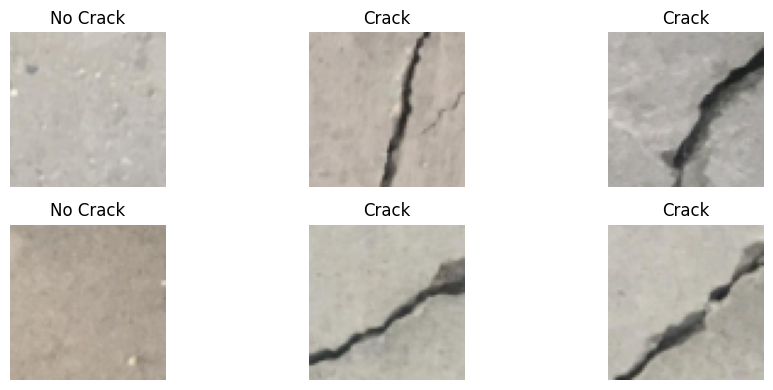

In [ ]:
# Visualize a few sample images from the training set to understand the data
# Label 0 = Negative (no crack), Label 1 = Positive (has crack)
images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 4))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    img = images[i] * 0.5 + 0.5  # Un-normalize for display
    plt.imshow(img.permute(1, 2, 0))
    label_name = "Crack" if labels[i].item() == 1 else "No Crack"
    plt.title(label_name)
    plt.axis("off")
plt.tight_layout()
plt.show()

#### CNN Architecture
We build a 3-layer CNN: each block applies **convolution → ReLU activation → max pooling** to progressively extract features at different scales and learn visual patterns that separate cracked and non-cracked surfaces.

In [ ]:
# Define a lightweight CNN model for binary crack classification
# Conv layers extract spatial features; FC layers make the final prediction
class CrackCNN(nn.Module):
    def __init__(self):
        super(CrackCNN, self).__init__()

        # 3 convolutional blocks: each doubles the filter count and halves spatial size
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 64 -> 32
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 32 -> 16
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 16 -> 8
        )

        # Fully connected layers map learned features to 2 class scores (crack / no crack)
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

#### Setting up training
This cell defines the loss function and optimizer, which guide how the CNN updates its weights during learning.

In [ ]:
# Initialize model, loss function (CrossEntropy for multi-class), and Adam optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CrackCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"Training on: {device}")
total_params = sum(p.numel() for p in model.parameters())
print(f"Total model parameters: {total_params:,}")

Training on: cuda
Total model parameters: 548,258


#### Training the CNN
During training, the model repeatedly sees batches of images, makes predictions, measures error, and updates its parameters.

In [ ]:
# Train the CNN for 5 epochs — each epoch loops over the full training set
# Loss should decrease each epoch as the model learns to detect cracks
epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()          # Clear gradients from previous step
        outputs = model(images)        # Forward pass
        loss = criterion(outputs, labels)
        loss.backward()                # Backpropagation
        optimizer.step()               # Update weights

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f}")

Epoch 1/5 | Loss: 0.4283
Epoch 2/5 | Loss: 0.1141
Epoch 3/5 | Loss: 0.0774
Epoch 4/5 | Loss: 0.0738
Epoch 5/5 | Loss: 0.0671


#### Evaluating model performance
Now we test the trained CNN on unseen data to measure how well it generalizes beyond the training set.

In [ ]:
# Evaluate the trained CNN on the held-out test set
# torch.no_grad() disables gradient computation — speeds up inference
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("Evaluation complete!")

Evaluation complete!


#### Visualizing the confusion matrix
The confusion matrix helps us see where the model predicts correctly and where it still makes mistakes.

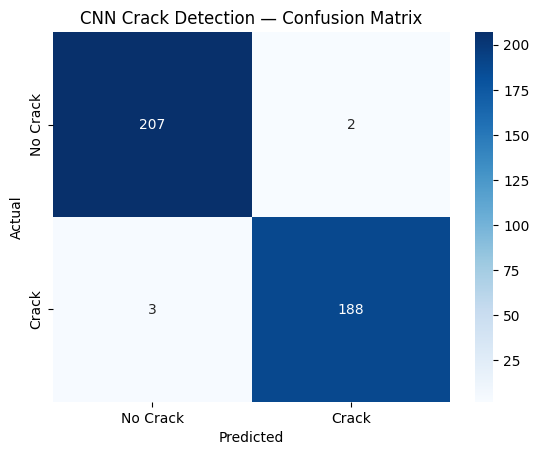

              precision    recall  f1-score   support

    No Crack       0.99      0.99      0.99       209
       Crack       0.99      0.98      0.99       191

    accuracy                           0.99       400
   macro avg       0.99      0.99      0.99       400
weighted avg       0.99      0.99      0.99       400



In [ ]:
# Plot a confusion matrix
# Rows = actual labels, Columns = predicted labels
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Crack", "Crack"],
            yticklabels=["No Crack", "Crack"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Crack Detection — Confusion Matrix")
plt.show()

print(classification_report(all_labels, all_preds, target_names=["No Crack", "Crack"]))

# Part 2: Transformer Neural Network
#### Conversational Chatbot with DialoGPT
Transformers use **self-attention** to relate every token to every other token in parallel — unlike RNNs which process tokens sequentially.


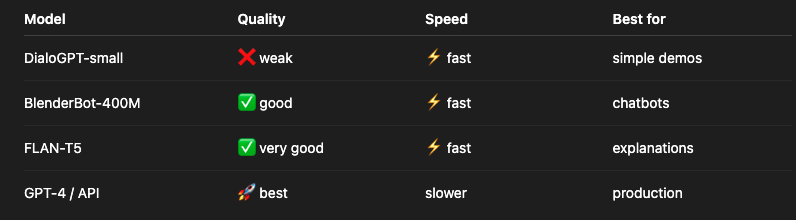

#### Loading a pretrained conversational transformer
This cell loads DialoGPT-small, a lightweight transformer chatbot model that is fast enough for notebook demonstrations.

In [ ]:
# Load Blenderbot
from transformers import BlenderbotTokenizer, BlenderbotForConditionalGeneration

# Load BlenderBot-400M Distill
model_name = "facebook/blenderbot-400M-distill"

tokenizer = BlenderbotTokenizer.from_pretrained(model_name)
chatbot = BlenderbotForConditionalGeneration.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
chatbot.to(device)
chatbot.eval()

print("Model loaded successfully!")
print("Running on device:", device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/16.0 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/355 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/730M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

Model loaded successfully!
Running on device: cuda


### Step 1: Tokenization — Text → Numbers
Transformers cannot read raw text. The **tokenizer** maps each word/subword to an integer ID from a fixed vocabulary. This step shows how the tokenizer converts text into token IDs and back again.

In [ ]:
# Show how BlenderBot tokenizes text
sample_text = "Nittany Data Labs is going to New York on April 9th and 10th!"

encoded = tokenizer(sample_text, return_tensors="pt")

print("Original text:")
print(sample_text)

print("\nInput IDs:")
print(encoded["input_ids"])

print("\nDecoded back:")
print(tokenizer.decode(encoded["input_ids"][0], skip_special_tokens=True))

Original text:
Nittany Data Labs is going to New York on April 9th and 10th!

Input IDs:
tensor([[   1,  432, 6923, 1378,  417, 2276,  493, 5215,  315,  655,  287, 2310,
         6210,  324,  349, 3178,   83, 1207,  536,  298, 1065,  536,    8,    2]])

Decoded back:
 Nittany Data Labs is going to New York on April 9th and 10th!


### Step 2: Generating a Response with a Pretrained Transformer

The prompt is first tokenized into numerical IDs that the model can process.
Those tokenized inputs are passed into BlenderBot, which generates a response one token at a time based on learned language patterns.

This cell demonstrates how a pretrained transformer turns an input prompt into a full natural-language reply using controlled text generation settings like sampling, temperature, and top-p.

In [ ]:
#Generate a single chatbot response
user_input = "What do you think makes someone a good friend?"

inputs = tokenizer([user_input], return_tensors="pt").to(device)

reply_ids = chatbot.generate(
    **inputs,
    max_new_tokens=50,
    min_new_tokens=8,
    do_sample=True,
    temperature=0.7,
    top_p=0.9
)

response = tokenizer.decode(reply_ids[0], skip_special_tokens=True)

print("User:", user_input)
print("Bot :", response)

User: What do you think makes someone a good friend?
Bot :  A good friend is someone who is there for you no matter what.


### Step 3: Single-Turn Generation
Generate a chatbot response for one user message using sampling strategies (top-k, top-p, temperature).

In [ ]:
# Helper function for single-turn chatting
def single_turn_chat(user_message):
    inputs = tokenizer([user_message], return_tensors="pt", truncation=True).to(device)

    reply_ids = chatbot.generate(
        **inputs,
        max_new_tokens=50,
        min_new_tokens=8,
        do_sample=True,
        temperature=0.7,
        top_p=0.9
    )

    response = tokenizer.decode(reply_ids[0], skip_special_tokens=True)
    return response

In [ ]:
# Generate a single chatbot response for a user message
user_message = "What helps people stay calm before a presentation?"
response = single_turn_chat(user_message)

print("User:", user_message)
print("Bot :", response)

User: What helps people stay calm before a presentation?
Bot :  I think it's just the fact that they are prepared.


### Step 4: Multi-Turn Chat — Context Matters!
Unlike RNNs, a Transformer reads the *entire conversation history* as one long sequence, so it can reference anything said earlier.

In [ ]:
# Helper function: append the new user message to the conversation history,
# then pass the full context to the model so it can attend to prior turns
def chat_with_bot(user_message, history=None, max_history_turns=3):
    """
    Multi-turn chatbot using short text history.
    BlenderBot works better with short conversation context,
    so we keep only the most recent few turns.
    """

    if history is None:
        history = []

    # Add the current user message to history
    history.append(f"User: {user_message}")

    # Keep only recent turns so input does not become too long
    recent_history = history[-max_history_turns * 2:]

    # Join conversation into one prompt
    conversation_text = " ".join(recent_history)

    inputs = tokenizer(
        [conversation_text],
        return_tensors="pt",
        truncation=True,
        max_length=128
    ).to(device)

    reply_ids = chatbot.generate(
        **inputs,
        max_new_tokens=40,
        min_new_tokens=6,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        no_repeat_ngram_size=3
    )

    response = tokenizer.decode(reply_ids[0], skip_special_tokens=True)

    # Save bot response into history
    history.append(f"Bot: {response}")

    return response, history

In [ ]:
# Run a short scripted conversation to see multi-turn context in action
history = []

conversation = [
    "Hi, how are you today?",
    "I've had a really busy week.",
    "What helps people deal with stress?"
]

for turn in conversation:
    response, history = chat_with_bot(turn, history)
    print(f"User: {turn}")
    print(f"Bot : {response}")
    print("-" * 60)

User: Hi, how are you today?
Bot :  I'm doing well. How are you?
------------------------------------------------------------
User: I've had a really busy week.
Bot :  I am good. I have had a busy week as well.
------------------------------------------------------------
User: What helps people deal with stress?
Bot :  I'm not sure, but I've been dealing with a lot of stress lately.
------------------------------------------------------------


We compare responses with and without prior context to show how transformers use earlier text in the conversation.

In [ ]:
### Show why context matters ###
msg1 = "I have a big presentation tomorrow."
msg2 = "What can I do to stay calm before speaking?"

# With history
history = []
_, history = chat_with_bot(msg1, history)
resp_with, _ = chat_with_bot(msg2, history)

# Without history
resp_without = single_turn_chat(msg2)

print("=== WITH conversation history ===")
print("User:", msg1)
print("User:", msg2)
print("Bot :", resp_with)

print("\n=== WITHOUT conversation history ===")
print("User:", msg2)
print("Bot :", resp_without)

=== WITH conversation history ===
User: I have a big presentation tomorrow.
User: What can I do to stay calm before speaking?
Bot :  It is a presentation for my job.

=== WITHOUT conversation history ===
User: What can I do to stay calm before speaking?
Bot :  Speaking is one of the most difficult things to do. You just have to try your best.


Even a smaller transformer contains millions of learned parameters, which helps explain both its power and its computational cost.

In [ ]:
# Count parameters to appreciate the scale of even a 'small' transformer
total     = sum(p.numel() for p in chatbot.parameters())
trainable = sum(p.numel() for p in chatbot.parameters() if p.requires_grad)

print(f"Total parameters    : {total:,}")
print(f"Trainable parameters: {trainable:,}")
print(f"(DialoGPT-medium has ~345M; GPT-3 has ~175B)")

Total parameters    : 395,553,280
Trainable parameters: 395,553,280
(DialoGPT-medium has ~345M; GPT-3 has ~175B)


# Try it yourself!
### Interactive chatbot demo
This optional loop lets you chat with the model directly and observe how it responds in real time.

In [ ]:
# Run this cell and type your own messages!
history = []

print("Interactive BlenderBot Chat — type 'quit' to stop\n")

while True:
    user_message = input("You: ")

    if user_message.lower().strip() == "quit":
        print("Chat ended.")
        break

    response, history = chat_with_bot(user_message, history)
    print(f"Bot: {response}\n")

Interactive BlenderBot Chat — type 'quit' to stop

You: What should our next lab topic be?
Bot:  I am not sure, but I am sure it will be interesting.

You: quit
Chat ended.
